# Punto 2 — Estadísticas del partido

**Proyecto Final · Curso LanusStats** · Lucas Marinelli · @datafutbol_ar

Partido: **Argentina 1–2 Arabia Saudita** — debut Mundial 2022 (`match_id 3857300`).

> Consigna: con la info del partido, averiguar **(1)** el equipo con más xG, **(2)** el
> jugador con más pases, **(3)** el jugador con más recuperaciones y **(4)** la zona de la
> cancha (en tercios) con más toques/acciones.

## Setup

In [ ]:
%load_ext autoreload # Permite recargar automáticamente los módulos editados sin tener que reiniciar el kernel
%autoreload 2 # Recarga todos los módulos cada vez que se ejecuta una celda

from helpers import *
import matplotlib.pyplot as plt

ev = cargar_eventos(MATCH_ARG_SAU, 'arg_sau')   # lee del cache
print('eventos:', ev.shape)

[cache] arg_sau: 3329 eventos leidos de eventos_arg_sau.parquet
eventos: (3329, 93)


## 1. Equipo con más xG

El xG (goles esperados) suma la probabilidad de gol de cada tiro. Lo agrupamos por equipo.

In [2]:
xg_equipo = (ev.groupby('team')['shot_statsbomb_xg']
              .sum()
              .sort_values(ascending=False)
              .round(2))
xg_equipo

team
Argentina       2.49
Saudi Arabia    0.15
Name: shot_statsbomb_xg, dtype: float64

**Lectura:** Argentina generó bastante más xG que Arabia Saudita y aun así perdió. Esa es
la historia del partido: el campeón fue más peligroso pero ineficaz (y le anularon tiros
por offside). El xG alto + resultado adverso es justo lo que hace interesante este debut.

## 2. Jugador con más pases

Filtramos los eventos de tipo `Pass` y contamos por jugador.

In [3]:
pases = ev[ev['type'] == 'Pass']['player'].value_counts()
pases.head(10)

player
Nicolás Hernán Otamendi            89
Rodrigo Javier De Paul             86
Nahuel Molina Lucero               68
Cristian Gabriel Romero            61
Leandro Daniel Paredes             57
Lionel Andrés Messi Cuccittini     46
Ángel Fabián Di María Hernández    41
Mohammed Kanoo                     38
Enzo Fernandez                     38
Abdulelah Saad Hameed Al-Malki     37
Name: count, dtype: int64

El líder de pases suele ser un central o un volante de salida — el que **construye** el juego.

## 3. Jugador con más recuperaciones

Las recuperaciones son el evento `Ball Recovery`: cuándo un jugador recupera una pelota suelta.

In [4]:
recuperaciones = ev[ev['type'] == 'Ball Recovery']['player'].value_counts()
recuperaciones.head(10)

player
Salem Mohammed Al Dawsari          8
Rodrigo Javier De Paul             8
Mohammed Kanoo                     7
Firas Tariq Nasser Al Albirakan    7
Abdulelah Saad Hameed Al-Malki     6
Damián Emiliano Martínez           6
Mohammed Khalil Al Owais           4
Nicolás Alejandro Tagliafico       3
Lionel Andrés Messi Cuccittini     3
Alejandro Darío Gómez              3
Name: count, dtype: int64

## 4. Zona de la cancha (tercios) con más toques

Dividimos la cancha a lo largo en tres tercios (la cancha StatsBomb mide 120 de largo):
**Defensivo** (0–40), **Medio** (40–80) y **Ofensivo** (80–120). Contamos acciones por tercio.

In [7]:
ev2 = añadir_xy(ev)   # agrega columnas x, y desde 'location'
ev2['tercio'] = pd.cut(ev2['x'], [0, 40, 80, 120],
                       labels=['Defensivo', 'Medio', 'Ofensivo'])
toques_por_tercio = ev2['tercio'].value_counts().sort_index()
toques_por_tercio

tercio
Defensivo     986
Medio        1491
Ofensivo      810
Name: count, dtype: int64

Si el tercio medio domina, el partido se jugó en mitad de cancha; si pesa el ofensivo,
hubo presión alta / juego en campo rival (coherente con el dominio de Argentina).

## Visualización — top pasadores del partido

Una barra horizontal con la identidad @datafutbol_ar (Combo C).

findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font f

[fig] guardada punto2_top_pasadores.png


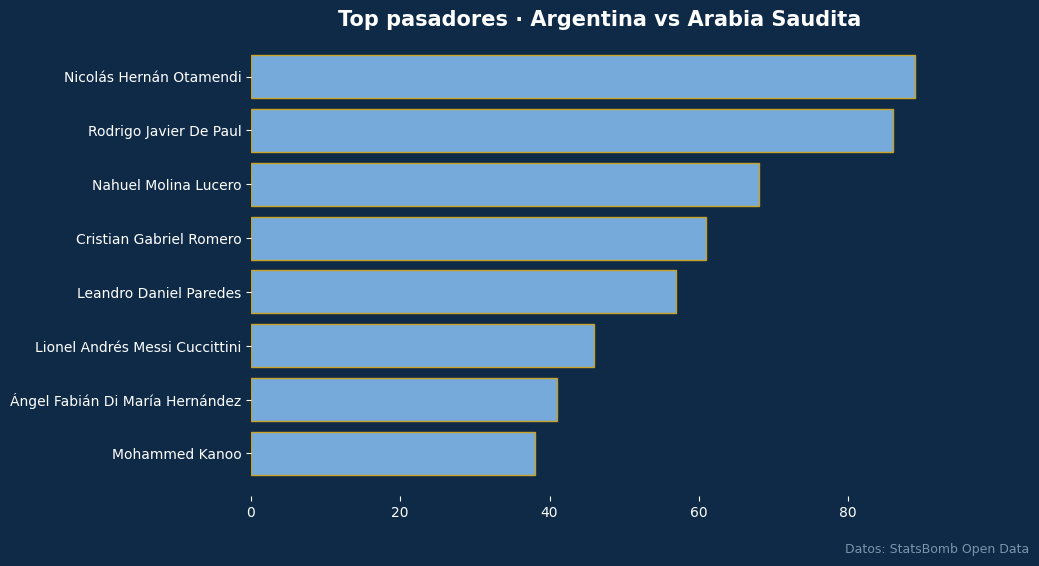

In [6]:
top = ev[ev['type'] == 'Pass']['player'].value_counts().head(8).sort_values()

fig, ax = plt.subplots(figsize=(9, 6), facecolor=COLORS['bg'])
ax.set_facecolor(COLORS['bg'])
ax.barh(top.index, top.values, color=COLORS['primary'], edgecolor=COLORS['accent'])
ax.set_title('Top pasadores · Argentina vs Arabia Saudita',
             color=COLORS['text'], fontsize=15, weight='bold')
ax.tick_params(colors=COLORS['text'])
for s in ax.spines.values():
    s.set_visible(False)
watermark(fig, 'Datos: StatsBomb Open Data')
guardar_fig(fig, 'punto2_top_pasadores')
plt.show()

## Resumen — Punto 2 ✅

| Pregunta | Respuesta |
|---|---|
| Equipo con más xG | Argentina (ver tabla §1) |
| Jugador con más pases | ver §2 |
| Jugador con más recuperaciones | ver §3 |
| Tercio con más toques | ver §4 |

**Conclusión:** Argentina dominó el juego (más xG, más toques en campo rival) pero perdió.
Los números explican la frustración del debut del campeón.

➡️ Sigue: **`punto_3.ipynb`** — mapas de tiros y de pases de ambos equipos.